In [33]:
import cv2
import matplotlib.pyplot as plt
import numpy as np



In [34]:
path = "img/car_img_2025-03-18_13-11-08.851761.jpg"
img = cv2.imread(path)

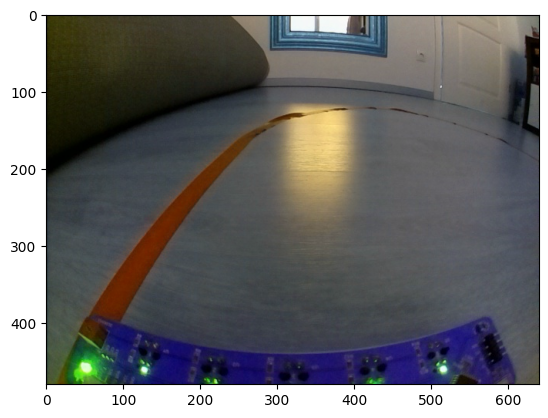

In [35]:
 plt.imshow(img)

In [36]:
img_crop = img[100:350,:,:]

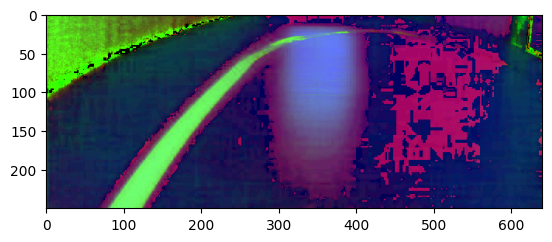

In [37]:
img_hsv = cv2.cvtColor(img_crop, cv2.COLOR_BGR2HSV)
plt.imshow(img_hsv)

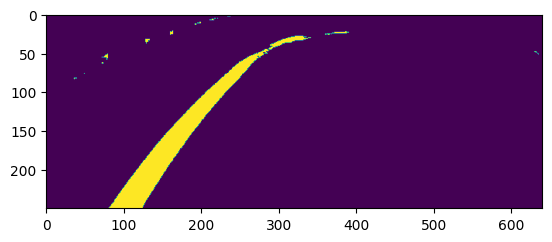

In [38]:
lower_blue = np.array([100, 150, 0])
upper_blue = np.array([140, 255, 255])
mask = cv2.inRange(img_hsv, lower_blue, upper_blue)
mask.shape
plt.imshow(mask)

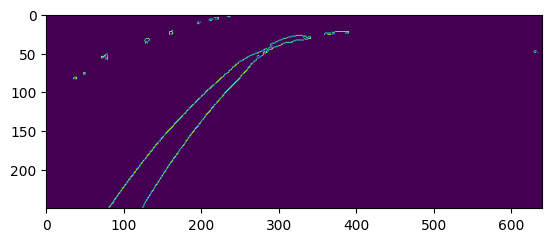

In [39]:
edges = cv2.Canny(mask, 50, 150, apertureSize=3)
plt.imshow(edges)

In [40]:
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)
print(lines)

[[[200 137 283  44]]

 [[ 81 248 143 166]]

 [[154 153 208  97]]

 [[181 124 245  64]]]


(1, 4)
(1, 4)
(1, 4)
(1, 4)


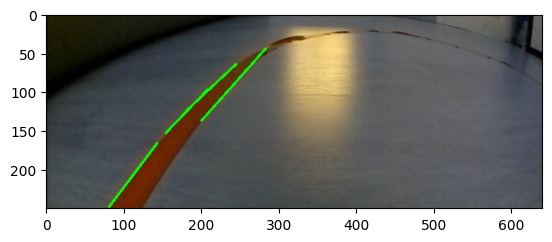

In [46]:
line_img = img_crop.copy()

if lines is not None:
    for line in lines:
       
        x1, y1, x2, y2 = line[0]
        
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        

plt.imshow(line_img[:,:,:])


In [48]:
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        
        # Berechnung der Steigung
        if (x2 - x1) != 0:
            slope = (y2 - y1) / (x2 - x1)
            angle_rad = np.arctan(slope)
            angle_deg = np.degrees(angle_rad) 
        else:
            slope = float('inf') 

        print(f"Linie von ({x1},{y1}) nach ({x2},{y2}) hat eine Steigung von {slope}, Winkel {angle_deg}")

Linie von (200,137) nach (283,44) hat eine Steigung von -1.1204819277108433, Winkel -48.25194560036388
Linie von (81,248) nach (143,166) hat eine Steigung von -1.3225806451612903, Winkel -52.90716270295846
Linie von (154,153) nach (208,97) hat eine Steigung von -1.037037037037037, Winkel -46.041626676009976
Linie von (181,124) nach (245,64) hat eine Steigung von -0.9375, Winkel -43.15238973400541
